In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans



In [3]:
data = pd.read_csv('Trips_2018/Trips_2018.csv')

In [4]:

print(data.head())
print(data.columns.tolist())
    

   Unnamed: 0  tripduration                 starttime  \
0           0           970  2018-01-01 13:50:57.4340   
1           1           723  2018-01-01 15:33:30.1820   
2           2           496  2018-01-01 15:39:18.3370   
3           3           306  2018-01-01 15:40:13.3720   
4           4           306  2018-01-01 18:14:51.5680   

                   stoptime  start_station_id  start_station_latitude  \
0  2018-01-01 14:07:08.1860              72.0               40.767272   
1  2018-01-01 15:45:33.3410              72.0               40.767272   
2  2018-01-01 15:47:35.1720              72.0               40.767272   
3  2018-01-01 15:45:20.1910              72.0               40.767272   
4  2018-01-01 18:19:57.6420              72.0               40.767272   

   start_station_longitude  end_station_id  end_station_latitude  \
0               -73.993929           505.0             40.749013   
1               -73.993929          3255.0             40.750585   
2             

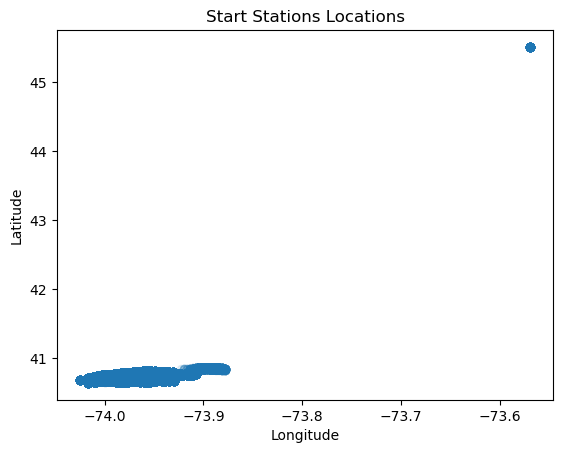

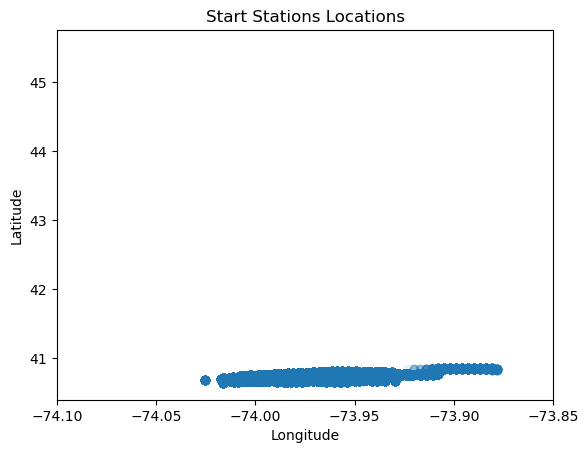

In [ ]:
plt.scatter(data['end_station_longitude'], data['end_station_latitude'], alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Locations')
# plt.xlim([-74.1, -73.85])
plt.show()

plt.scatter(data['end_station_longitude'], data['end_station_latitude'], alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Locations')
plt.xlim([-74.1, -73.85])
plt.ylim([40.6, 40.9])
plt.show()


In [8]:
# Remove rows with lattude larger than 44
data_ = data[data['start_station_latitude'] < 44]
data_ = data[data['end_station_latitude'] < 44]

# Print id's of stations with latitude larger than 44
print(data_[data_['start_station_latitude'] > 44]['start_station_id'].unique())
print(data_[data_['end_station_latitude'] > 44]['end_station_id'].unique())


[]
[]


In [9]:
'''
    We seem to have all stations in the end time station id column, but not in the start time station id column.
'''

# Concat all stations
all_stations = pd.concat([data_['start_station_id'], data_['end_station_id']])
all_stations = all_stations.drop_duplicates().reset_index(drop=True)

# Count unique start stations
unique_start_stations = all_stations.nunique()
print(f'Unique start stations: {unique_start_stations}')

# Count unique end stations
unique_end_stations = data_['end_station_id'].nunique()
print(f'Unique end stations: {unique_end_stations}')

# Count unique end stations
unique_end_stations = data_['start_station_id'].nunique()
print(f'Unique start stations: {unique_end_stations}')

Unique start stations: 848
Unique end stations: 848
Unique start stations: 816


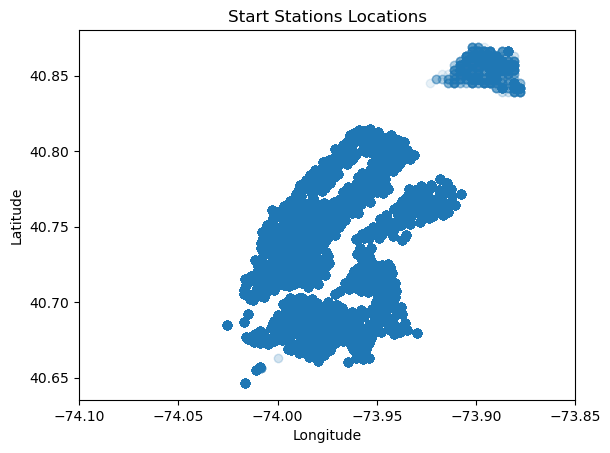

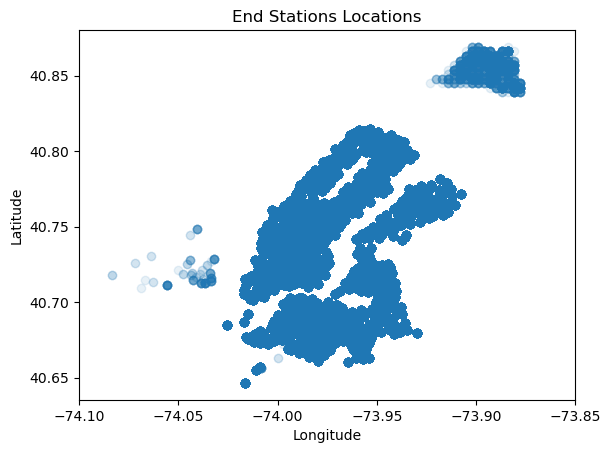

In [ ]:
# See the distribution of start and end stations
plt.scatter(data_['start_station_longitude'], data_['start_station_latitude'], alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Start Stations Locations')
plt.xlim([-74.1, -73.85])
plt.show()

plt.scatter(data_['end_station_longitude'], data_['end_station_latitude'], alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Locations')
plt.xlim([-74.1, -73.85])
plt.show()



/tmp/ipykernel_11961/1101295815.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_['end_station_cluster'] = kmeans.fit_predict(data_[['end_station_longitude', 'end_station_latitude']])


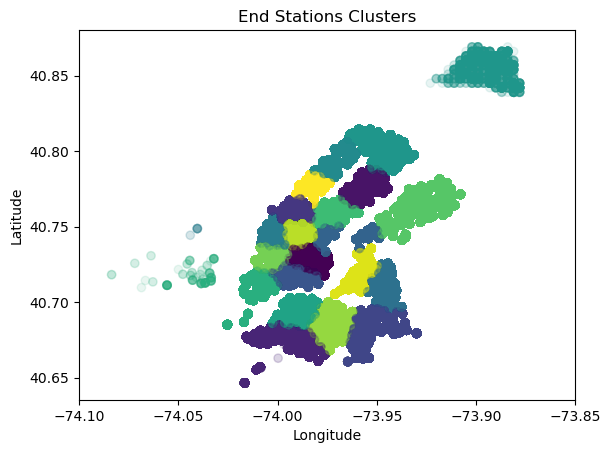

In [ ]:
# Perform k-means clustering to on the end staion, based on longitude and latitude
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=20)
data_['end_station_cluster'] = kmeans.fit_predict(data_[['end_station_longitude', 'end_station_latitude']])
plt.scatter(data_['end_station_longitude'], data_['end_station_latitude'], c=data_['end_station_cluster'], cmap='viridis', alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Clusters')
plt.xlim([-74.1, -73.85])
plt.show()

/tmp/ipykernel_11961/1101295815.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_['end_station_cluster'] = kmeans.fit_predict(data_[['end_station_longitude', 'end_station_latitude']])


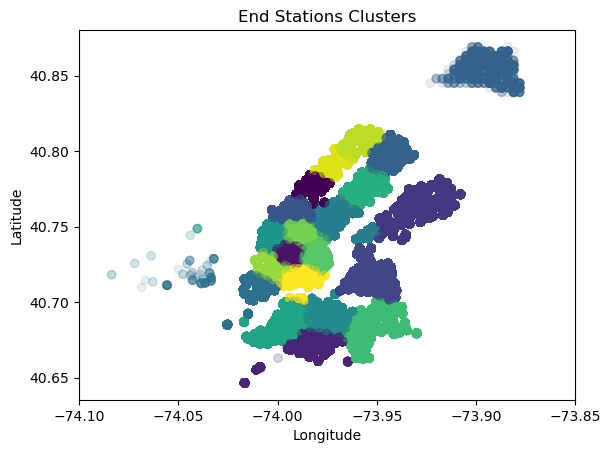

In [ ]:
# Perform k-means clustering to on the end staion, based on longitude and latitude
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=20)
data_['end_station_cluster'] = kmeans.fit_predict(data_[['end_station_longitude', 'end_station_latitude']])
plt.scatter(data_['end_station_longitude'], data_['end_station_latitude'], c=data_['end_station_cluster'], cmap='viridis', alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Clusters')
plt.xlim([-74.1, -73.85])
plt.show()

   station_id   latitude  longitude
0        72.0  40.767272 -73.993929
1        79.0  40.719116 -74.006667
2        82.0  40.711174 -74.000165
3        83.0  40.683826 -73.976323
4       119.0  40.696089 -73.978034


/tmp/ipykernel_14953/2643153996.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_['end_station_cluster'] = kmeans.fit_predict(data_[['end_station_longitude', 'end_station_latitude']])


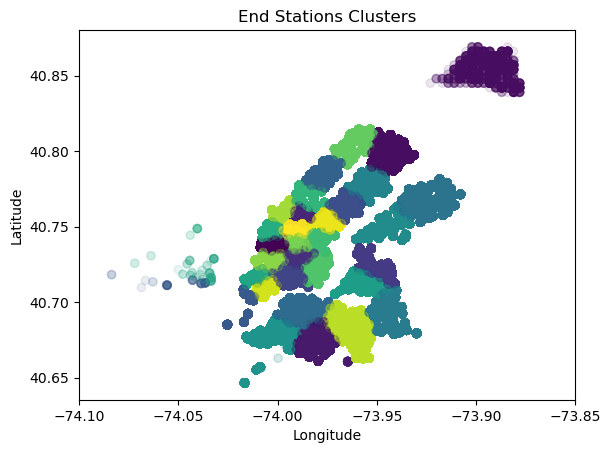

In [12]:
# Extract station_id and start_station_latitude, start_station_longitude
stations_start = data_[['start_station_id', 'start_station_latitude', 'start_station_longitude']]
stations_start.columns = ['station_id', 'latitude', 'longitude']

stations_end = data_[['end_station_id', 'end_station_latitude', 'end_station_longitude']]
stations_end.columns = ['station_id', 'latitude', 'longitude']

# Combine start and end stations
stations = pd.concat([stations_start, stations_end]).drop_duplicates().reset_index(drop=True)
print(stations.head())

kmeans = KMeans(n_clusters=30)
data_['end_station_cluster'] = kmeans.fit_predict(data_[['end_station_longitude', 'end_station_latitude']])
plt.scatter(data_['end_station_longitude'], data_['end_station_latitude'], c=data_['end_station_cluster'], cmap='viridis', alpha=0.1)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('End Stations Clusters')
plt.xlim([-74.1, -73.85])
plt.show()


In [ ]:
# Join end station cluster back to data dataframe
data = data_.merge(stations[['station_id', 'latitude', 'longitude']], left_on='start_station_id', right_on='station_id', how='left', suffixes=('', '_end'))
